---CHENNAI WATER MANAGEMENT INSIGHTS---
Peak Storage reached on:2011-01-14with10568.0mcft
Potential Drought years identified:[2004, 2017, 2019]


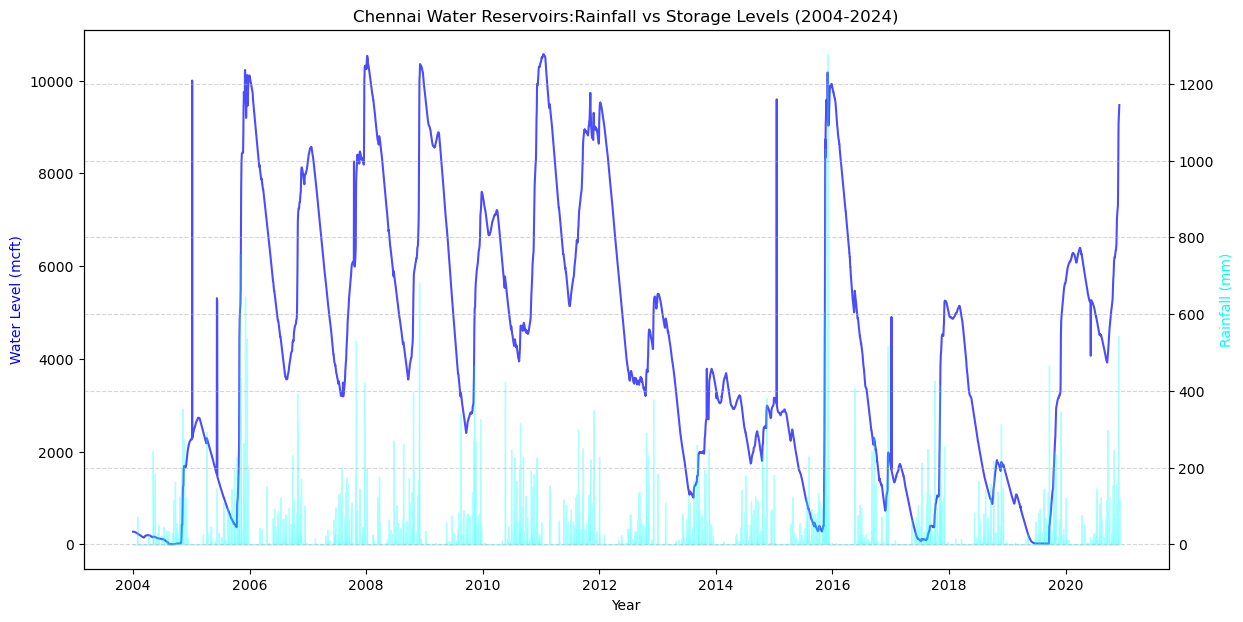

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
rain_df=pd.read_csv("chennai_reservoir_rainfall.csv")
level_df=pd.read_csv("chennai_reservoir_levels.csv")
rain_df.columns=['Date','Rain_Poondi','Rain_Cholavaram','Rain_Redhills','Rain_Chembarambakkam']
level_df.columns=['Date','Level_Poondi','Level_Cholavaram','Level_Redhills','Level_Chembarambakkam']
df=pd.merge(rain_df,level_df,on='Date')
df['Date']=pd.to_datetime(df['Date'],dayfirst=True)
reservoirs=['Poondi','Cholavaram','Redhills','Chembarambakkam']
rain_cols=[f'Rain_{res}'for res in reservoirs]
level_cols=[f'Level_{res}'for res in reservoirs]
df['Total_Rainfall']=np.sum(df[rain_cols].values,axis=1)
df['Total_Level']=np.sum(df[level_cols].values,axis=1)
df['Rolling_Rain_30']=df['Total_Rainfall'].rolling(window=30).mean()
mean_rain=np.mean(df['Total_Rainfall'])
std_rain=np.std(df['Total_Rainfall'])
df['Is_Heavy_Rain'] = np.where(df['Total_Rainfall'] > (mean_rain + 2*std_rain), 1, 0)
df['Year']=df['Date'].dt.year
yearly_summary=df.groupby('Year').agg({
    'Total_Rainfall':'sum',
    'Total_Level':'mean'
}).reset_index()
plt.figure(figsize=(14,7))
ax1=plt.gca()
ax2=ax1.twinx()
ax1.plot(df['Date'],df['Total_Level'],color='blue',label='Total Water Level (mcft)',alpha=0.7)
ax2.fill_between(df['Date'],df['Total_Rainfall'],color='cyan',label='Daily Rainfall (mm)',alpha=0.3)
ax1.set_xlabel('Year')
ax1.set_ylabel('Water Level (mcft)',color='blue')
ax2.set_ylabel('Rainfall (mm)',color='cyan')
plt.title('Chennai Water Reservoirs:Rainfall vs Storage Levels (2004-2024)')
plt.grid(True,which='both',linestyle='--',alpha=0.5)
plt.savefig('chennai_water_trend.png')
print("---CHENNAI WATER MANAGEMENT INSIGHTS---")
max_storage_day = df.loc[df['Total_Level'].idxmax()]
print(f"Peak Storage reached on:{max_storage_day['Date'].date()}with{max_storage_day['Total_Level']}mcft")
drought_years=yearly_summary[yearly_summary['Total_Level']<yearly_summary['Total_Level'].mean()*0.5]
print(f"Potential Drought years identified:{list(drought_years['Year'])}")